In [1]:
from src.baseline_config import build_training_config
from src.phase3.config import PHASE3_FILTER_PARAMS, PHASE3_SSIM_THRESHOLD, PHASE3_PHASH_THRESHOLD
from src.phase3.experiment import (
    PHASE3_SOURCE_CSV,
    curate_phase3_p3m_keep70_dataset,
    print_phase3_dataset_summary,
    print_phase3_summary,
    print_phase3_test_summary,
    run_phase3_processing,
    show_phase3_plots,
    train_phase3_dataset,
)

TRAINING_CONFIG = build_training_config(architecture="vit_small")


In [2]:
print_phase3_dataset_summary(PHASE3_SOURCE_CSV)

Rows: 13296
histology
Adenoma                     8313
Sessile_serrated_adenoma    3047
Hyperplastic                1421
Adenocarcinoma               515


In [3]:
phase3_result = curate_phase3_p3m_keep70_dataset(force_score=False)

phase3_result["output_csv"]

WindowsPath('phase3/phase3_p3m_conf060_keep70.csv')

In [4]:
print_phase3_dataset_summary(phase3_result["output_csv"])

Rows: 10128
histology
Adenoma                     6292
Sessile_serrated_adenoma    2350
Hyperplastic                1095
Adenocarcinoma               391


In [5]:
train_phase3_dataset(
    train_csv=phase3_result["output_csv"],
    descriptor=phase3_result["descriptor"],
    force_train=False,
    training_config=TRAINING_CONFIG,
)

Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase3\p3m_conf060_keep70\seed_1\best_baseline_model.pth


c:\Users\luis\Documents\TFG - Data-Centric AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase3\p3m_conf060_keep70\seed_2\best_baseline_model.pth
Loss weights: {'Adenoma': 0.2988, 'Sessile_serrated_adenoma': 0.5954, 'Hyperplastic': 1.0162, 'Adenocarcinoma': 2.0895}


Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase3\p3m_conf060_keep70\seed_3


Training Progress:  76%|███████▌  | 76/100 [2:01:19<38:18, 95.78s/epoch, Stage=full_network, Train Loss=0.0560, Val Loss=0.4355, Val Macro F1=0.6256, Selection Score=-0.6256, Best Epoch=61, LR=1.0e-07/1.0e-07]         


Early stopping triggered after 16 epochs without improving macro_f1.
Optimization sequence completed with seed 456. Selected checkpoint macro-F1: 0.6359 with validation loss 0.4319 and validation score -0.6359 at epoch 61.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase3\p3m_conf060_keep70\seed_3'.
Loss weights: {'Adenoma': 0.2988, 'Sessile_serrated_adenoma': 0.5954, 'Hyperplastic': 1.0162, 'Adenocarcinoma': 2.0895}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase3\p3m_conf060_keep70\seed_4


Training Progress:  28%|██▊       | 28/100 [42:51<1:50:11, 91.83s/epoch, Stage=full_network, Train Loss=0.0515, Val Loss=0.4778, Val Macro F1=0.6129, Selection Score=-0.6129, Best Epoch=13, LR=6.3e-07/6.3e-06]       

Early stopping triggered after 16 epochs without improving macro_f1.


Optimization sequence completed with seed 789. Selected checkpoint macro-F1: 0.6185 with validation loss 0.3831 and validation score -0.6185 at epoch 13.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\ViT-Small\phase3\p3m_conf060_keep70\seed_4'.


'p3m_conf060_keep70'

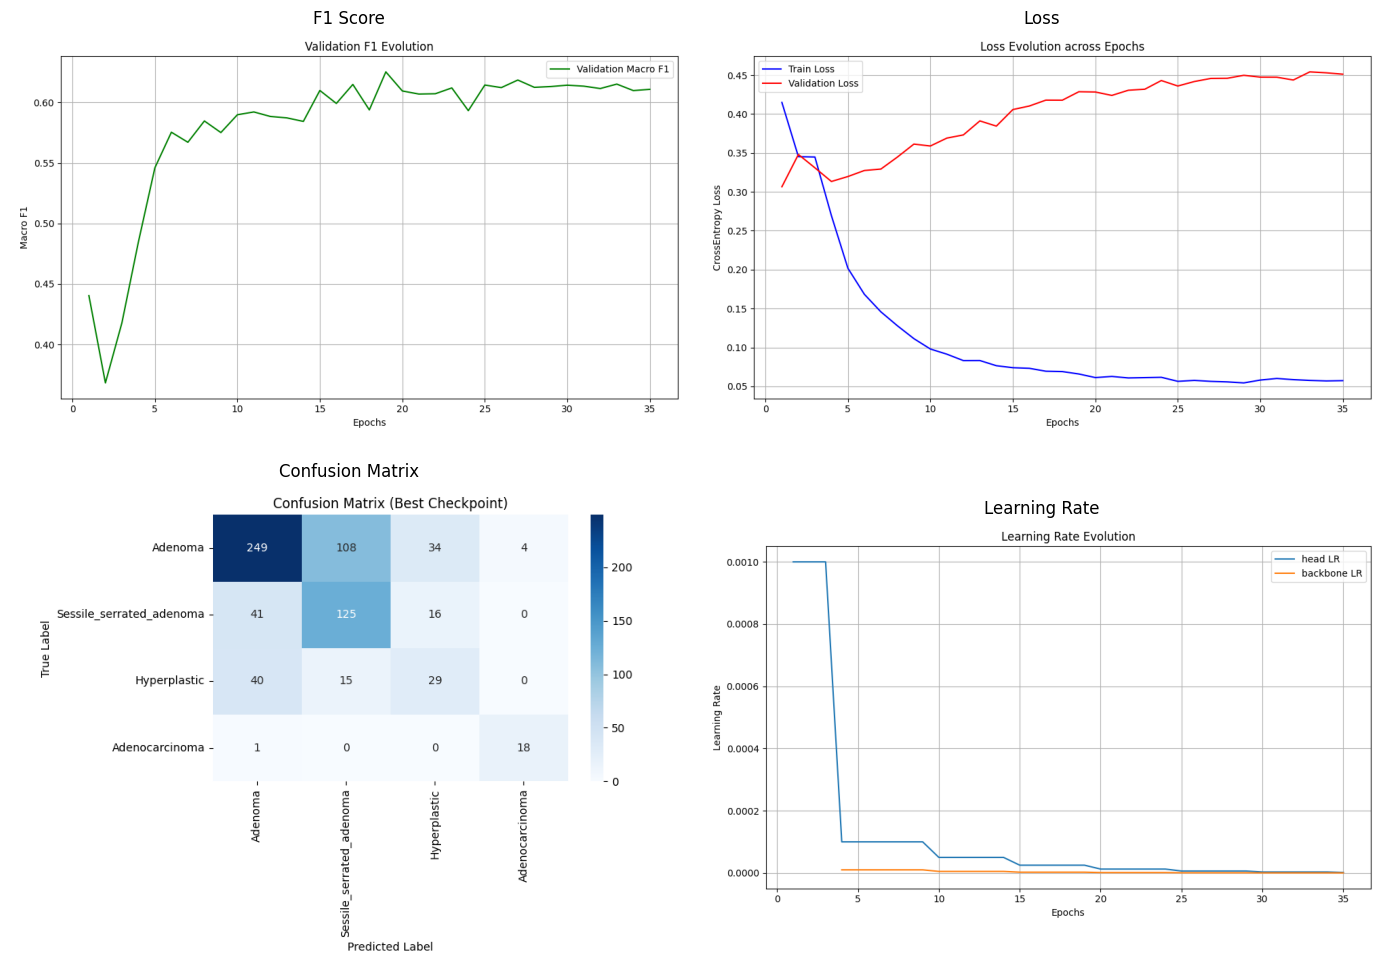

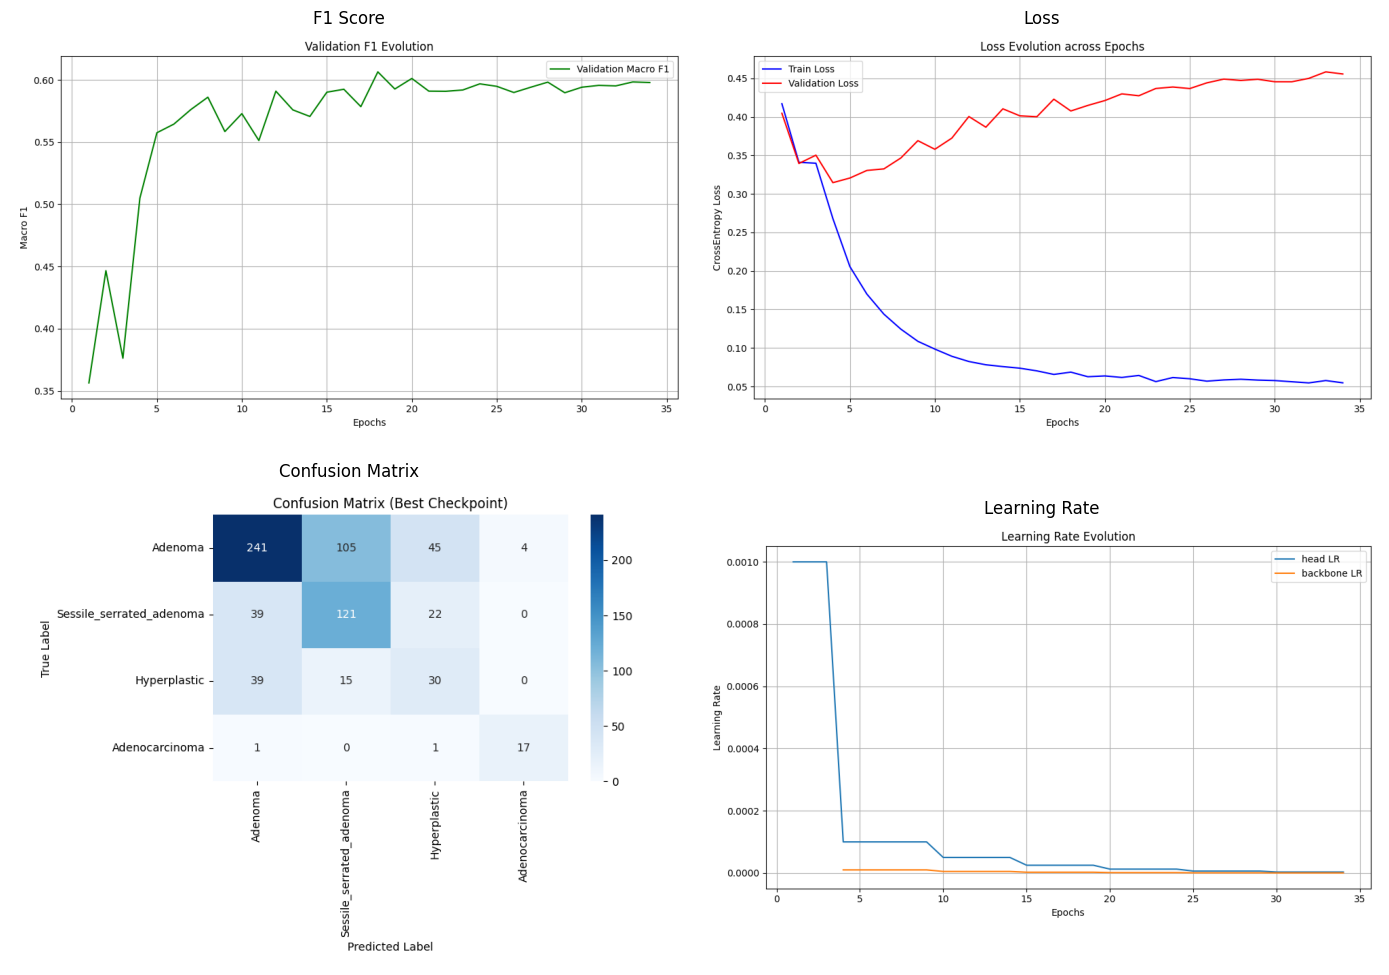

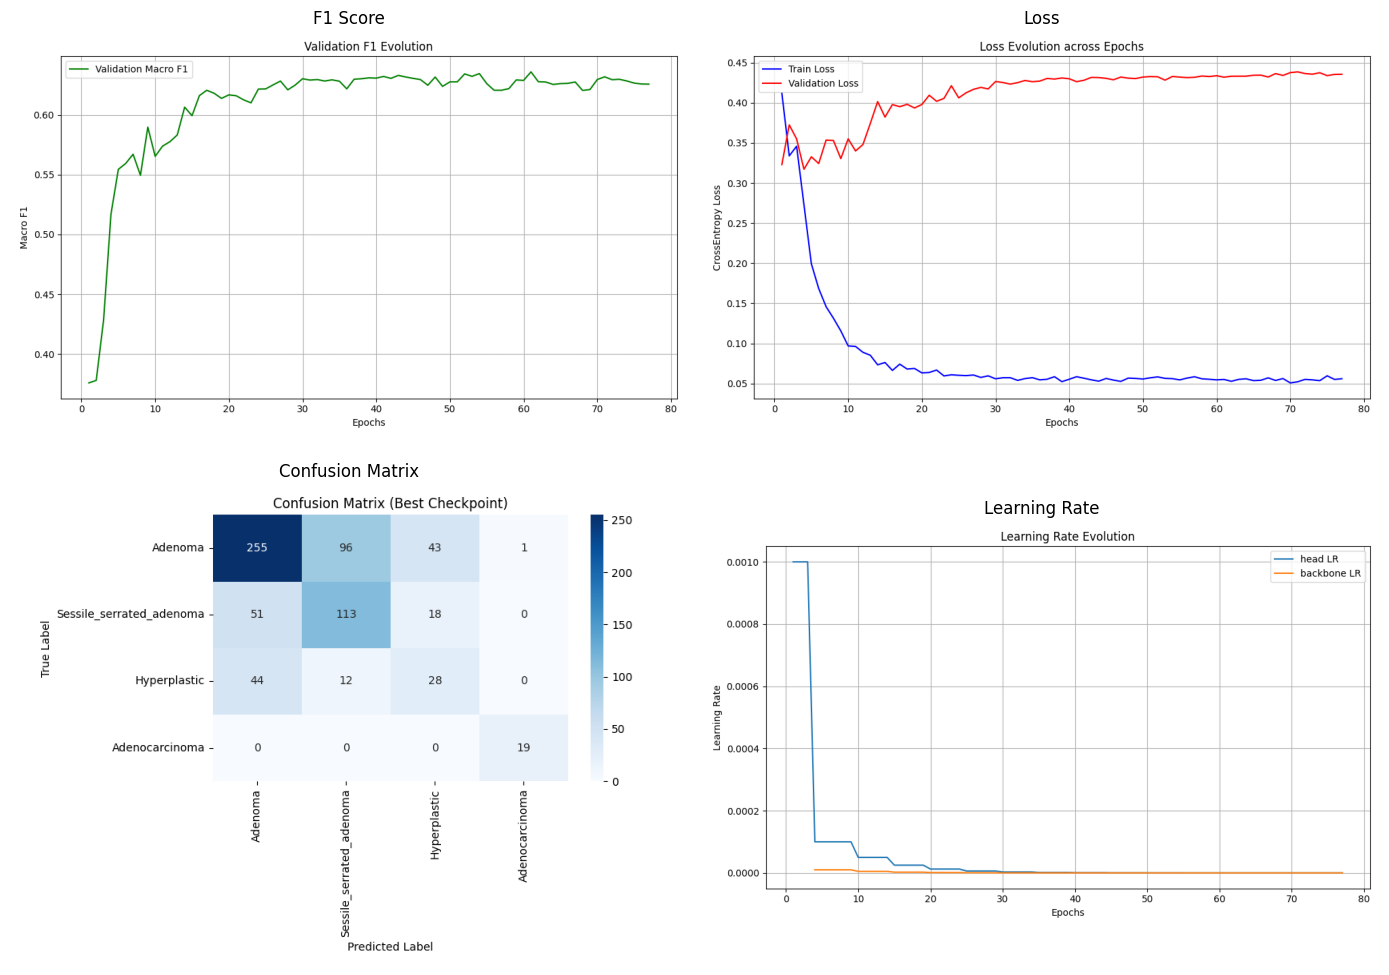

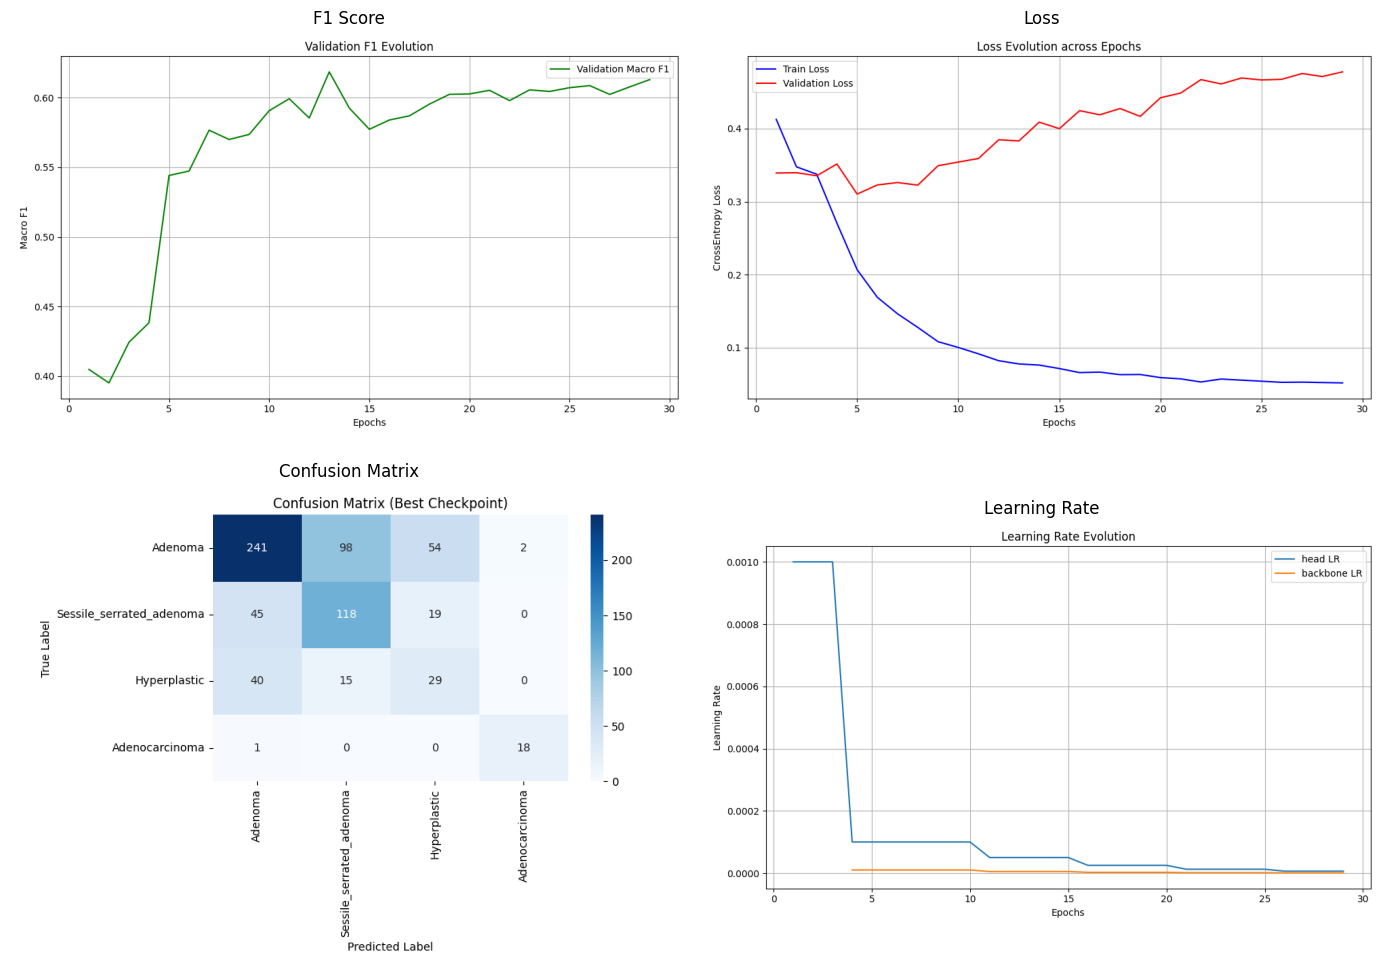

In [6]:
show_phase3_plots(
    train_csv=phase3_result["output_csv"],
    descriptor=phase3_result["descriptor"],
    training_config=TRAINING_CONFIG,
)

In [7]:
print_phase3_summary(
    train_csv=phase3_result["output_csv"],
    descriptor=phase3_result["descriptor"],
    training_config=TRAINING_CONFIG,
)

,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.6070 +/- 0.0098,0.3566 +/- 0.0136,0.6215 +/- 0.0123,0.6093 +/- 0.0137,0.6430 +/- 0.0099
1,Adenoma,0.6559 +/- 0.0073,0.3200 +/- 0.0163,0.6781 +/- 0.0087,0.7427 +/- 0.0120,0.6241 +/- 0.0172
2,Sessile_serrated_adenoma,0.7371 +/- 0.0030,0.3932 +/- 0.0093,0.5714 +/- 0.0084,0.5071 +/- 0.0047,0.6552 +/- 0.0278
3,Hyperplastic,0.8265 +/- 0.0144,0.2317 +/- 0.0265,0.3303 +/- 0.0186,0.3180 +/- 0.0351,0.3452 +/- 0.0097
4,Adenocarcinoma,0.9945 +/- 0.0033,0.9046 +/- 0.0554,0.9064 +/- 0.0544,0.8694 +/- 0.0674,0.9474 +/- 0.0430


In [8]:
print_phase3_test_summary(
    train_csv=phase3_result["output_csv"],
    descriptor=phase3_result["descriptor"],
    training_config=TRAINING_CONFIG,
)

,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.4051 +/- 0.0198,0.2510 +/- 0.0219,0.3471 +/- 0.0149,0.4525 +/- 0.0156,0.4651 +/- 0.0150
1,Adenoma,0.6360 +/- 0.0083,0.2363 +/- 0.0340,0.4953 +/- 0.0258,0.4179 +/- 0.0117,0.6094 +/- 0.0554
2,Sessile_serrated_adenoma,0.7278 +/- 0.0210,0.1028 +/- 0.0105,0.0659 +/- 0.0055,0.0347 +/- 0.0030,0.6528 +/- 0.0278
3,Hyperplastic,0.6659 +/- 0.0175,0.0756 +/- 0.0525,0.2218 +/- 0.0508,0.4090 +/- 0.0624,0.1536 +/- 0.0416
4,Adenocarcinoma,0.7805 +/- 0.0068,0.5457 +/- 0.0154,0.6053 +/- 0.0166,0.9486 +/- 0.0136,0.4446 +/- 0.0177
